# Purpose
This notebook describes the typical activities carried out  at the beginning to a project / thread when customer shares new data. We will be trying to understand the tables, columns and information flow. Typically we also look for data issues and confirm with respective owners for resolution. At the end of this activity, the data sources and their treatment is finalized. Code in this notebook will not be part of the production code.

This data can be downloaded from
[here](https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.tgz)

**NOTE**:
Download the data from the above link, and copy the extracted csv files to the path `data/raw/housing/` (relative to root of the code archive folder). Make sure to copy the files before continuing on with the rest of the notebook.

# Initialization

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba import NumbaDeprecationWarning
from dateutil.parser import UnknownTimezoneWarning

warnings.filterwarnings('ignore', message="The default value of regex will change from True to False in a future version.", 
                        category=FutureWarning)

warnings.filterwarnings("ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings("ignore", category=UnknownTimezoneWarning)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
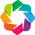

CPU times: user 10.8 s, sys: 6.28 s, total: 17.1 s
Wall time: 1min 8s


In [3]:
%%time

# Third-party imports
import os.path as op
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import great_expectations as ge

# Project imports
from ta_lib.core.api import display_as_tabs, initialize_environment

# Initialization
initialize_environment(debug=False, hide_warnings=True)

# Data

## Background

The dataset contains information about California districts and their corresponding median house values.

The objective of this project is to understand the factors associated with variation in house prices and develop regression models to predict `median_house_value`.

The raw dataset contains geographical information, housing characteristics, population statistics, household information, median income, and ocean proximity.

In [4]:
from ta_lib.core.api import create_context, list_datasets, load_dataset

In [5]:
config_path = op.join('conf', 'config.yml')
context = create_context(config_path)

print("Core configuration:")
print(context.config["core"])

Core configuration:
{'random_seed': 0, 'data_base_path': '/mnt/c/capstone_project_house_price_prediction/src/../data', 'log_base_path': '/mnt/c/capstone_project_house_price_prediction/src/../logs'}


In [6]:
list_datasets(context)

['/raw/housing',
 '/cleaned/housing',
 '/processed/housing',
 '/train/housing/features',
 '/train/housing/target',
 '/test/housing/features',
 '/test/housing/target',
 '/score/housing/output']

In [7]:
# load datasets
housing_df = load_dataset(context, 'raw/housing')

print("Shape:", housing_df.shape)
housing_df.head(5)

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
#List the columns of the housing dataset
housing_df.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [9]:
#First 5 rows and last 5 rows of the housing dataset
display(housing_df.head())
display(housing_df.tail())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [10]:
#data types of the housing dataset
housing_df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

# Exploratory Analysis

Given the raw data from data ingestion, we would now like to explore and learn more details about the data.


The output of the step would be a summary report and discussion of any pertinent findings.


In [11]:
# Import the eda API
import ta_lib.eda.api as eda

## Variable summary

In [12]:
display_as_tabs([('housing', housing_df.shape)])

Tabs
    [0] Str(tuple, name='housing')

In [13]:
sum1 = eda.get_variable_summary(housing_df)

display_as_tabs([('housing', sum1)])

Tabs
    [0] DataFrame(height=300, name='housing', sizing_mode='fixed', value=                         V..., width=800)

In [14]:
housing_df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

**Dev NOTES**

<details>
1. Datatypes : We have both numeric and other types. The bulk of them seem to be numeric. `Numeric` is defined to be one of float.



In [15]:
variable_summary = eda.get_variable_summary(housing_df)
display(variable_summary)

,Variable Name,Datatype,No of Unique,Samples
longitude,longitude,float64,844,"[-122.23, -122.22, -122.24, -122.25, -122.26]"
latitude,latitude,float64,862,"[37.88, 37.86, 37.85, 37.84, 37.83]"
housing_median_age,housing_median_age,float64,52,"[41.0, 21.0, 52.0, 42.0, 50.0]"
total_rooms,total_rooms,float64,5926,"[880.0, 7099.0, 1467.0, 1274.0, 1627.0]"
total_bedrooms,total_bedrooms,float64,1923,"[129.0, 1106.0, 190.0, 235.0, 280.0]"
population,population,float64,3888,"[322.0, 2401.0, 496.0, 558.0, 565.0]"
households,households,float64,1815,"[126.0, 1138.0, 177.0, 219.0, 259.0]"
median_income,median_income,float64,12928,"[8.3252, 8.3014, 7.2574, 5.6431, 3.8462]"
median_house_value,median_house_value,float64,3842,"[452600.0, 358500.0, 352100.0, 341300.0, 34220..."
ocean_proximity,ocean_proximity,object,5,"[NEAR BAY, <1H OCEAN, INLAND, NEAR OCEAN, ISLAND]"


##Missing-value analysis

In [16]:
missing_summary = housing_df.isna().sum().sort_values(ascending=False)

display(missing_summary)

total_bedrooms        207
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [17]:
missing_analysis = pd.DataFrame({
    "missing_count": housing_df.isna().sum(),
    "missing_percentage": housing_df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_analysis)

,missing_count,missing_percentage
total_bedrooms,207,1.002907
longitude,0,0.000000
latitude,0,0.000000
housing_median_age,0,0.000000
total_rooms,0,0.000000
population,0,0.000000
households,0,0.000000
median_income,0,0.000000
median_house_value,0,0.000000
ocean_proximity,0,0.000000


### Observation

Only `total_bedrooms` contains missing values. There are 207 missing observations out of 20,640 records, representing approximately 1% of the dataset.

Since the number of missing observations is relatively small, the records do not need to be discarded. The missing values can be handled during data processing using an appropriate imputation strategy.

## Duplicate analysis

In [18]:
duplicate_count = housing_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [19]:
print(
    "Duplicate percentage:",
    round(housing_df.duplicated().mean() * 100, 3),
    "%"
)

Duplicate percentage: 0.0 %


## Categorical analysis

In [20]:
housing_df["ocean_proximity"].value_counts(dropna=False)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [21]:
housing_df["ocean_proximity"].value_counts(normalize=True).mul(100).round(2)

ocean_proximity
<1H OCEAN     44.26
INLAND        31.74
NEAR OCEAN    12.88
NEAR BAY      11.09
ISLAND         0.02
Name: proportion, dtype: float64

In [22]:
plt.figure(figsize=(8, 5))
housing_df["ocean_proximity"].value_counts().plot(kind="bar")
plt.title("Distribution of Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Number of Districts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/mnt/c/capstone_project_house_price_prediction/ta-lib-dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(



/mnt/c/capstone_project_house_price_prediction/ta-lib-dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(



/tmp/ipykernel_236110/3481769915.py:8: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



## Target-variable analysis

In [23]:
target = "median_house_value"

housing_df[target].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(housing_df[target], bins=50)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/2902573127.py:7: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



In [25]:
housing_df[target].skew()

0.9777632739098341

## Numeric-variable distributions

In [26]:
import numpy as np
numeric_columns = housing_df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [27]:
housing_df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## Outlier analysis

In [28]:
outlier_summary = eda.get_outliers(housing_df[numeric_columns])
display(outlier_summary)

,N,< (mean-3*std),> (mean+3*std),< (1stQ - 1.5 * IQR),> (3rdQ + 1.5 * IQR),-inf,+inf
Feature,,,,,,,
total_rooms,20640,0,373,0,1287,0,0
total_bedrooms,20640,0,368,0,1271,0,0
population,20640,0,342,0,1196,0,0
households,20640,0,363,0,1220,0,0
median_income,20640,0,345,0,681,0,0
median_house_value,20640,0,0,0,1071,0,0


## Correlation analysis

In [29]:
correlation = housing_df[numeric_columns].corr()

display(correlation)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/813362739.py:11: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



In [31]:
target_correlation = (
    correlation["median_house_value"]
    .sort_values(ascending=False)
)

display(target_correlation)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## Feature vs target analysis

In [32]:
# Median income vs house value
plt.figure(figsize=(8, 5))
plt.scatter(
    housing_df["median_income"],
    housing_df["median_house_value"],
    alpha=0.2
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/3068337702.py:12: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



In [33]:
#Housing age vs house value
plt.figure(figsize=(8, 5))
plt.scatter(
    housing_df["housing_median_age"],
    housing_df["median_house_value"],
    alpha=0.2
)
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.title("Housing Median Age vs Median House Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/2527281494.py:12: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



## Geographic analysis

In [34]:
#Longitude and latitude are particularly interesting for this dataset.
plt.figure(figsize=(10, 7))
plt.scatter(
    housing_df["longitude"],
    housing_df["latitude"],
    s=5,
    alpha=0.3
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Housing Districts")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/4268967534.py:13: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



In [35]:
# Then house price geographically:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    housing_df["longitude"],
    housing_df["latitude"],
    c=housing_df["median_house_value"],
    s=5,
    alpha=0.4
)

plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Median House Value")
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/3485279196.py:17: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



## House value by ocean proximity

In [36]:
housing_df.groupby("ocean_proximity")[
    "median_house_value"
].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median", ascending=False)

,count,mean,median,min,max
ocean_proximity,,,,,
ISLAND,5,380440.000000,414700.0,287500.0,450000.0
NEAR BAY,2290,259212.311790,233800.0,22500.0,500001.0
NEAR OCEAN,2658,249433.977427,229450.0,22500.0,500001.0
<1H OCEAN,9136,240084.285464,214850.0,17500.0,500001.0
INLAND,6551,124805.392001,108500.0,14999.0,500001.0


In [37]:
plt.figure(figsize=(9, 5))
housing_df.boxplot(
    column="median_house_value",
    by="ocean_proximity",
    figsize=(9, 5)
)
plt.title("Median House Value by Ocean Proximity")
plt.suptitle("")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_236110/1398749359.py:13: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()



## Housing-density features for EDA

In [38]:
eda_df = housing_df.copy()

eda_df["rooms_per_household"] = (
    eda_df["total_rooms"] / eda_df["households"]
)

eda_df["bedrooms_per_room"] = (
    eda_df["total_bedrooms"] / eda_df["total_rooms"]
)

eda_df["population_per_household"] = (
    eda_df["population"] / eda_df["households"]
)

In [39]:
eda_df[
    [
        "rooms_per_household",
        "bedrooms_per_room",
        "population_per_household",
        "median_house_value"
    ]
].describe()

,rooms_per_household,bedrooms_per_room,population_per_household,median_house_value
count,20640.000000,20433.000000,20640.000000,20640.000000
mean,5.429000,0.213039,3.070655,206855.816909
std,2.474173,0.057983,10.386050,115395.615874
min,0.846154,0.100000,0.692308,14999.000000
25%,4.440716,0.175427,2.429741,119600.000000
50%,5.229129,0.203162,2.818116,179700.000000
75%,6.052381,0.239821,3.282261,264725.000000
max,141.909091,1.000000,1243.333333,500001.000000


## Health Analysis

In [40]:
health_summary, health_plot = eda.get_data_health_summary(
    housing_df,
    return_plot=True
)

display(health_summary)
display(health_plot)

values
type              labels               
Datatypes         Numeric     90.000000
                  Others      10.000000
Missing Values    Available   99.899709
                  Missing      0.100291
Duplicate Values  Unique     100.000000
                  Duplicate    0.000000
Duplicate Columns Unique     100.000000
                  Duplicate    0.000000

:Layout
   .Bars.I   :Bars   [index,labels]   (value)
   .Bars.II  :Bars   [index,labels]   (value)
   .Bars.III :Bars   [index,labels]   (value)
   .Bars.IV  :Bars   [index,labels]   (value)

In [41]:
#missing values summary and plot
missing_summary, missing_plot = eda.get_missing_values_summary(
    housing_df,
    return_plot=True
)

display(missing_summary)
display(missing_plot)

,Variable Name,No of Missing,Per of Missing
4,total_bedrooms,207,1.002907
0,longitude,0,0.000000
1,latitude,0,0.000000
2,housing_median_age,0,0.000000
3,total_rooms,0,0.000000
5,population,0,0.000000
6,households,0,0.000000
7,median_income,0,0.000000
8,median_house_value,0,0.000000
9,ocean_proximity,0,0.000000


:Bars   [index]   (0)

In [42]:
#Duplicate columns
duplicate_columns = eda.get_duplicate_columns(housing_df)

display(duplicate_columns)

'No duplicate variables'

## Health Analysis report

Generate a report that has all the above data in a single html. This could be useful to submit to a client

In [43]:
from ta_lib.reports.api import summary_report

summary_report(housing_df, 'reports/housing.html')